In [47]:
import pandas as pd

In [48]:
datos = pd.read_csv('/content/datos_limpios.csv')

In [49]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customerID          7267 non-null   object 
 1   Churn               7043 non-null   float64
 2   gender              7267 non-null   object 
 3   SeniorCitizen       7267 non-null   int64  
 4   Partner             7267 non-null   int64  
 5   Dependents          7267 non-null   int64  
 6   Antiguedad_Cliente  7267 non-null   int64  
 7   PhoneService        7267 non-null   int64  
 8   MultipleLines       7267 non-null   object 
 9   InternetService     7267 non-null   object 
 10  OnlineSecurity      5686 non-null   float64
 11  OnlineBackup        5686 non-null   float64
 12  DeviceProtection    5686 non-null   float64
 13  TechSupport         5686 non-null   float64
 14  StreamingTV         5686 non-null   float64
 15  StreamingMovies     5686 non-null   float64
 16  Contra

In [50]:
datos = datos.drop(columns=['customerID'])

In [51]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Churn               7043 non-null   float64
 1   gender              7267 non-null   object 
 2   SeniorCitizen       7267 non-null   int64  
 3   Partner             7267 non-null   int64  
 4   Dependents          7267 non-null   int64  
 5   Antiguedad_Cliente  7267 non-null   int64  
 6   PhoneService        7267 non-null   int64  
 7   MultipleLines       7267 non-null   object 
 8   InternetService     7267 non-null   object 
 9   OnlineSecurity      5686 non-null   float64
 10  OnlineBackup        5686 non-null   float64
 11  DeviceProtection    5686 non-null   float64
 12  TechSupport         5686 non-null   float64
 13  StreamingTV         5686 non-null   float64
 14  StreamingMovies     5686 non-null   float64
 15  Contract            7267 non-null   object 
 16  Paperl

In [52]:
datos = pd.get_dummies(datos, drop_first=True)

In [53]:
datos.head()

,Churn,SeniorCitizen,Partner,Dependents,Antiguedad_Cliente,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,gender_Male,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,0,1,1,9,1,0.0,1.0,0.0,1.0,...,False,False,False,False,False,True,False,False,False,True
1,0.0,0,0,0,9,1,0.0,0.0,0.0,0.0,...,True,False,True,False,False,False,False,False,False,True
2,1.0,0,0,0,4,1,0.0,0.0,1.0,0.0,...,True,False,False,True,False,False,False,False,True,False
3,1.0,1,1,0,13,1,0.0,1.0,1.0,0.0,...,True,False,False,True,False,False,False,False,True,False
4,1.0,1,1,0,3,1,0.0,0.0,0.0,1.0,...,False,False,False,True,False,False,False,False,False,True


In [54]:
datos['Churn'].value_counts(normalize=True)

,proportion
Churn,
0.0,0.73463
1.0,0.26537


In [55]:
from imblearn.over_sampling import SMOTE

In [56]:
X = datos.drop('Churn', axis=1)
y = datos['Churn']

In [57]:
datos = datos.dropna(subset=['Churn'])

In [58]:
datos['Churn'].isnull().sum()

np.int64(0)

In [59]:
X = datos.drop('Churn', axis=1)
y = datos['Churn']

In [60]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_res, y_res = smote.fit_resample(X, y)

ValueError: Input X contains NaN.
SMOTE does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [61]:
datos = datos.dropna()

In [62]:
datos.isnull().sum()

,0
Churn,0
SeniorCitizen,0
Partner,0
Dependents,0
Antiguedad_Cliente,0
PhoneService,0
OnlineSecurity,0
OnlineBackup,0
DeviceProtection,0
TechSupport,0


In [63]:
X = datos.drop('Churn', axis=1)
y = datos['Churn']

In [64]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_res, y_res = smote.fit_resample(X, y)

In [65]:
y_res.value_counts()

,count
Churn,
0.0,3756
1.0,3756


In [66]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [67]:
correlacion = datos.corr()

correlacion

,Churn,SeniorCitizen,Partner,Dependents,Antiguedad_Cliente,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,gender_Male,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
Churn,1.000000,0.120978,-0.161626,-0.147970,-0.397735,0.055215,-0.280508,-0.195758,-0.176806,-0.274112,...,-0.008608,-0.055215,0.002414,0.243811,NaN,-0.190665,-0.289471,-0.147738,0.270623,-0.042573
SeniorCitizen,0.120978,1.000000,0.018216,-0.207502,0.000371,0.042203,-0.110155,-0.003253,-0.011162,-0.135289,...,-0.005245,-0.042203,0.114462,0.200824,NaN,-0.051475,-0.100878,-0.033569,0.134855,-0.114798
Partner,-0.161626,0.018216,1.000000,0.422281,0.388864,0.021149,0.171581,0.173154,0.187386,0.144021,...,0.028197,-0.021149,0.139027,0.001406,NaN,0.105792,0.238660,0.094177,-0.101571,-0.095011
Dependents,-0.147970,-0.207502,0.422281,1.000000,0.175971,-0.029538,0.157478,0.096695,0.084184,0.136108,...,0.013940,0.029538,-0.012165,-0.131841,NaN,0.086979,0.171472,0.078273,-0.135462,0.021998
Antiguedad_Cliente,-0.397735,0.000371,0.388864,0.175971,1.000000,0.016399,0.377664,0.423038,0.423383,0.374344,...,0.011340,-0.016399,0.326149,0.000575,NaN,0.270003,0.572593,0.238987,-0.259894,-0.192490
PhoneService,0.055215,0.042203,0.021149,-0.029538,0.016399,1.000000,-0.037132,0.014632,-0.005223,-0.040368,...,-0.009551,-1.000000,0.357971,0.424662,NaN,-0.011264,-0.041017,-0.008304,0.056949,-0.078408
OnlineSecurity,-0.280508,-0.110155,0.171581,0.157478,0.377664,-0.037132,1.000000,0.179488,0.170099,0.273270,...,-0.017665,0.037132,0.033684,-0.222298,NaN,0.137746,0.343595,0.139150,-0.238458,0.036515
OnlineBackup,-0.195758,-0.003253,0.173154,0.096695,0.423038,0.014632,0.179488,1.000000,0.185021,0.190381,...,-0.013786,-0.014632,0.147274,-0.014056,NaN,0.122254,0.257787,0.111449,-0.127821,-0.073532
DeviceProtection,-0.176806,-0.011162,0.187386,0.084184,0.423383,-0.005223,0.170099,0.185021,1.000000,0.235564,...,0.001218,0.005223,0.146834,-0.000848,NaN,0.145464,0.328887,0.136819,-0.130950,-0.092512
TechSupport,-0.274112,-0.135289,0.144021,0.136108,0.374344,-0.040368,0.273270,0.190381,0.235564,1.000000,...,-0.008291,0.040368,0.035166,-0.211913,NaN,0.132677,0.408903,0.141169,-0.242566,0.031326


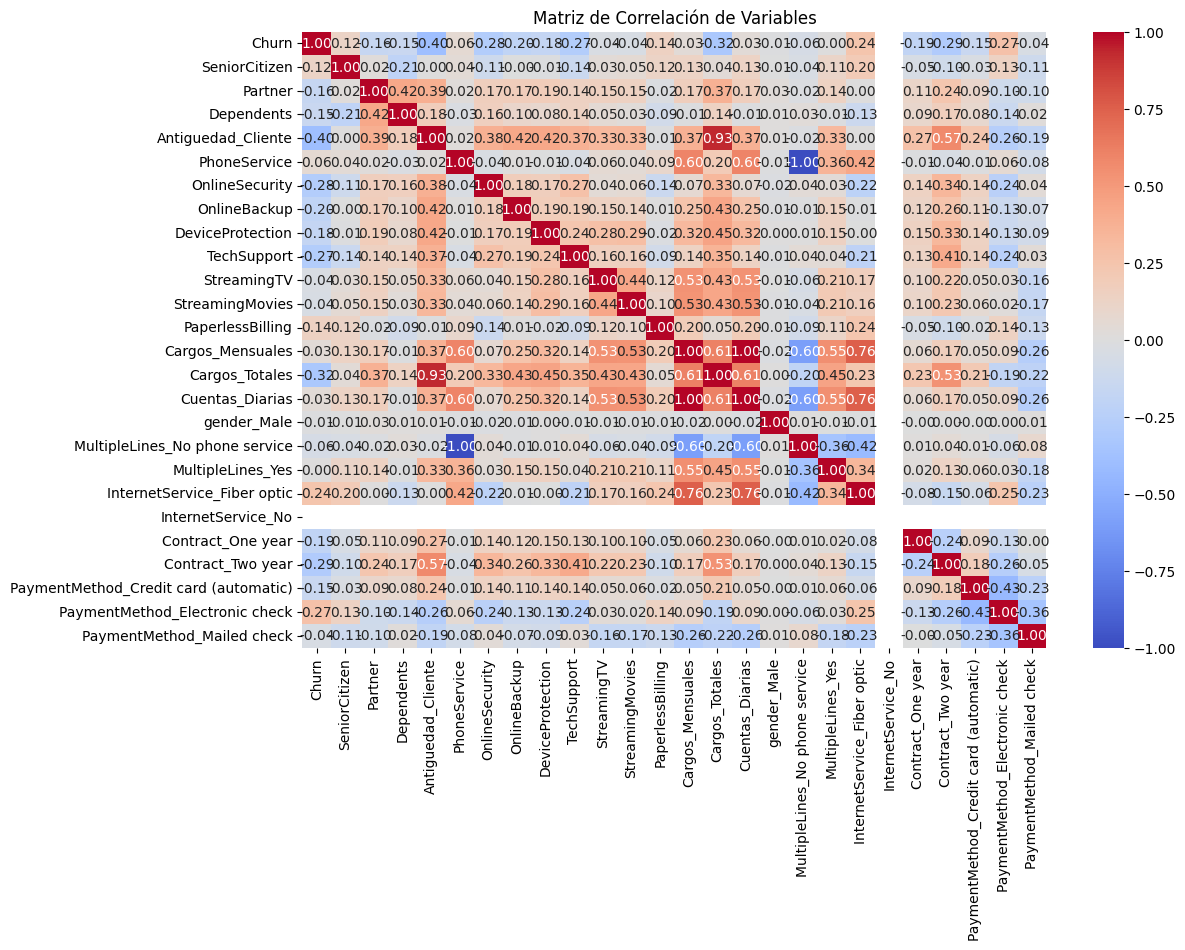

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Matriz de Correlación de Variables')

plt.show()

In [69]:
datos.corr()['Churn'].sort_values(ascending=False)

,Churn
Churn,1.000000
PaymentMethod_Electronic check,0.270623
InternetService_Fiber optic,0.243811
PaperlessBilling,0.142987
SeniorCitizen,0.120978
PhoneService,0.055215
Cargos_Mensuales,0.033239
Cuentas_Diarias,0.033239
MultipleLines_Yes,0.002414
gender_Male,-0.008608


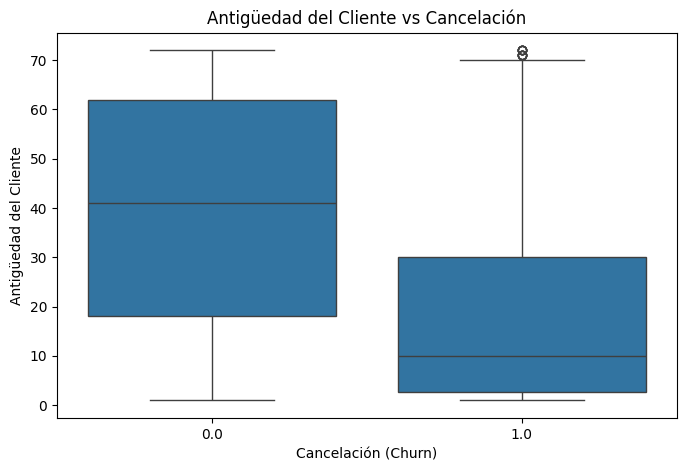

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='Antiguedad_Cliente', data=datos)

plt.title('Antigüedad del Cliente vs Cancelación')
plt.xlabel('Cancelación (Churn)')
plt.ylabel('Antigüedad del Cliente')

plt.show()

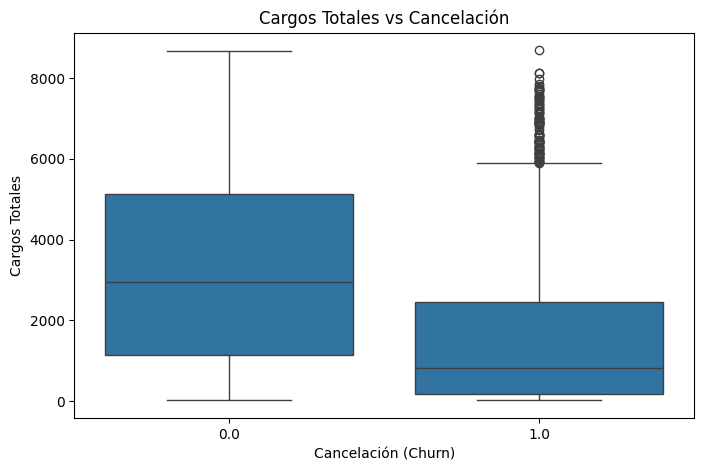

In [71]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='Cargos_Totales', data=datos)

plt.title('Cargos Totales vs Cancelación')
plt.xlabel('Cancelación (Churn)')
plt.ylabel('Cargos Totales')

plt.show()

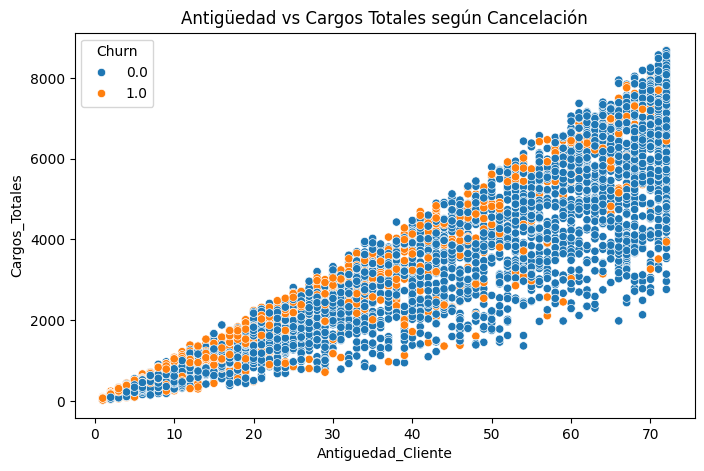

In [72]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='Antiguedad_Cliente', y='Cargos_Totales', hue='Churn', data=datos)

plt.title('Antigüedad vs Cargos Totales según Cancelación')

plt.show()

In [73]:
from sklearn.model_selection import train_test_split

In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res,
    y_res,
    test_size=0.3,
    random_state=42
)

In [75]:
print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (5258, 25)
Prueba: (2254, 25)


In [76]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [77]:
from sklearn.linear_model import LogisticRegression

modelo_log = LogisticRegression(max_iter=1000)

modelo_log.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [78]:
y_pred_log = modelo_log.predict(X_test_scaled)

In [79]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(random_state=42)

In [80]:
modelo_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [81]:
y_pred_rf = modelo_rf.predict(X_test)

In [82]:
from sklearn.metrics import classification_report

print("Regresión Logística")
print(classification_report(y_test, y_pred_log))

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Regresión Logística
              precision    recall  f1-score   support

         0.0       0.77      0.74      0.75      1110
         1.0       0.76      0.79      0.77      1144

    accuracy                           0.76      2254
   macro avg       0.76      0.76      0.76      2254
weighted avg       0.76      0.76      0.76      2254

Random Forest
              precision    recall  f1-score   support

         0.0       0.78      0.82      0.80      1110
         1.0       0.82      0.78      0.80      1144

    accuracy                           0.80      2254
   macro avg       0.80      0.80      0.80      2254
weighted avg       0.80      0.80      0.80      2254



In [83]:
from sklearn.metrics import accuracy_score

print("Accuracy Regresión Logística:", accuracy_score(y_test, y_pred_log))
print("Accuracy Random Forest:", accuracy_score(y_test, y_pred_rf))

Accuracy Regresión Logística: 0.7639751552795031
Accuracy Random Forest: 0.7999112688553682


In [84]:
from sklearn.metrics import classification_report

print("Reporte Regresión Logística")
print(classification_report(y_test, y_pred_log))

print("Reporte Random Forest")
print(classification_report(y_test, y_pred_rf))

Reporte Regresión Logística
              precision    recall  f1-score   support

         0.0       0.77      0.74      0.75      1110
         1.0       0.76      0.79      0.77      1144

    accuracy                           0.76      2254
   macro avg       0.76      0.76      0.76      2254
weighted avg       0.76      0.76      0.76      2254

Reporte Random Forest
              precision    recall  f1-score   support

         0.0       0.78      0.82      0.80      1110
         1.0       0.82      0.78      0.80      1144

    accuracy                           0.80      2254
   macro avg       0.80      0.80      0.80      2254
weighted avg       0.80      0.80      0.80      2254



In [85]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

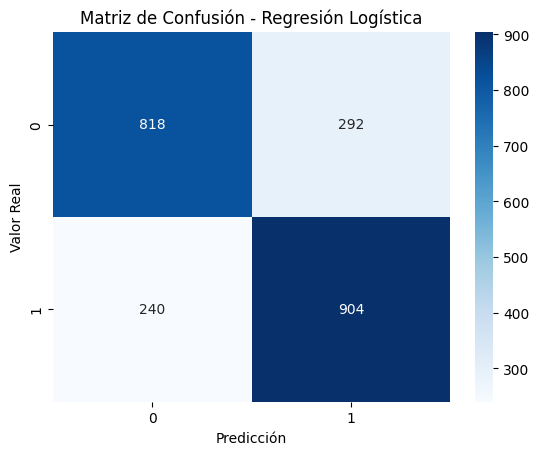

In [86]:
cm_log = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')

plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

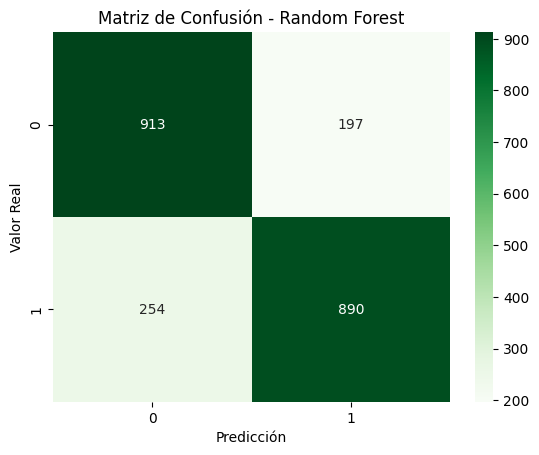

In [87]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')

plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

In [88]:
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo_log.coef_[0]
})

coeficientes = coeficientes.sort_values(by='Coeficiente', ascending=False)

coeficientes.head(10)

,Variable,Coeficiente
18,InternetService_Fiber optic,1.544426
13,Cargos_Totales,0.979109
23,PaymentMethod_Electronic check,0.723957
17,MultipleLines_Yes,0.550708
9,StreamingTV,0.509870
10,StreamingMovies,0.449665
22,PaymentMethod_Credit card (automatic),0.430661
24,PaymentMethod_Mailed check,0.367238
15,gender_Male,0.201754
7,DeviceProtection,0.136913


In [89]:
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo_rf.feature_importances_
})

importancias = importancias.sort_values(by='Importancia', ascending=False)

importancias.head(10)

,Variable,Importancia
3,Antiguedad_Cliente,0.140439
13,Cargos_Totales,0.130331
14,Cuentas_Diarias,0.097386
12,Cargos_Mensuales,0.096416
23,PaymentMethod_Electronic check,0.077717
5,OnlineSecurity,0.071937
8,TechSupport,0.070068
6,OnlineBackup,0.039235
18,InternetService_Fiber optic,0.035876
7,DeviceProtection,0.030732


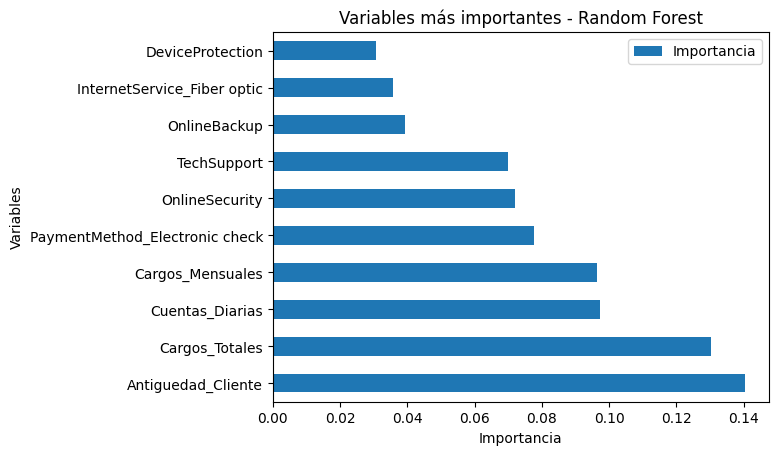

In [90]:
import matplotlib.pyplot as plt

importancias.head(10).plot(
    x='Variable',
    y='Importancia',
    kind='barh'
)

plt.title("Variables más importantes - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variables")

plt.show()